# 06 — Does Squad Market Value Improve Predictions?

Adds a second feature alongside Elo difference: log-ratio of squad market values (top-23 by value, from Transfermarkt via `salimt/football-datasets`).

Both features feed a multinomial logistic regression with three classes (away win / draw / home win). Walk-forward backtest WC 2010–2022 (skipping 2002 and 2006 — market-value coverage is too thin pre-2008).

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

from src.elo import EloModel
from src.draw_model import match_outcome
from src import transfermarkt as tm

%matplotlib inline

## Load competitive matches and pre-computed squad values

`matches_with_squad_value.csv` was built once via `tm.squad_value_for_matches(..., snapshot='year')` — covers matches since 2005 with both home and away top-23 squad values (in EUR).

In [2]:
df_all = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df_all = df_all.dropna(subset=['home_score', 'away_score'])
df_sv = pd.read_csv('../data/processed/matches_with_squad_value.csv', parse_dates=['date'])

print(f'Full match history: {len(df_all):,}')
print(f'With squad values:  {len(df_sv):,}')
print(f'Both nonzero:       {((df_sv["home_top_n_value_eur"] > 0) & (df_sv["away_top_n_value_eur"] > 0)).sum():,}')

Full match history: 21,220
With squad values:  12,395
Both nonzero:       7,773


## Compute pre-match Elo for the full history

Re-fit Elo through the entire dataset and merge `home_elo_pre` / `away_elo_pre` onto the squad-value frame.

In [3]:
elo = EloModel()
elo_enriched = elo.fit(df_all)
elo_cols = ['date', 'home_team', 'away_team', 'home_elo_pre', 'away_elo_pre']
df = df_sv.merge(elo_enriched[elo_cols], on=['date', 'home_team', 'away_team'], how='left')
df = df.dropna(subset=['home_elo_pre', 'away_elo_pre'])
print(f'Joined: {len(df):,} matches')

Joined: 12,395 matches


## Build features and outcome label

In [4]:
HOME_ADVANTAGE = 100
df['neutral'] = df['neutral'].fillna(False)
df['eff_elo_diff'] = (df['home_elo_pre'] + (~df['neutral']).astype(int) * HOME_ADVANTAGE) - df['away_elo_pre']
df['elo_diff_norm'] = df['eff_elo_diff'] / 400.0

# Squad value log-ratio. Use a floor to avoid log(0); 1e5 EUR is well below any realistic squad.
FLOOR = 1e5
df['log_value_diff'] = np.log10((df['home_top_n_value_eur'].clip(lower=FLOOR)) /
                                 (df['away_top_n_value_eur'].clip(lower=FLOOR)))

df['outcome'] = df.apply(lambda r: match_outcome(r['home_score'], r['away_score']), axis=1)

# Keep only matches where both teams have meaningful squad data
valid = df[(df['home_top_n_value_eur'] > FLOOR) & (df['away_top_n_value_eur'] > FLOOR)].copy()
print(f'Training-eligible matches: {len(valid):,}')
print(valid[['elo_diff_norm', 'log_value_diff']].describe().round(3))

Training-eligible matches: 7,620
       elo_diff_norm  log_value_diff
count       7620.000        7620.000
mean           0.208           0.049
std            0.434           1.103
min           -1.601          -3.998
25%           -0.074          -0.665
50%            0.195           0.046
75%            0.479           0.770
max            2.077           3.998


## Feature correlation

If squad value is mostly redundant with Elo, adding it as a second feature won't help.

Correlation between Elo diff and log value diff: 0.758


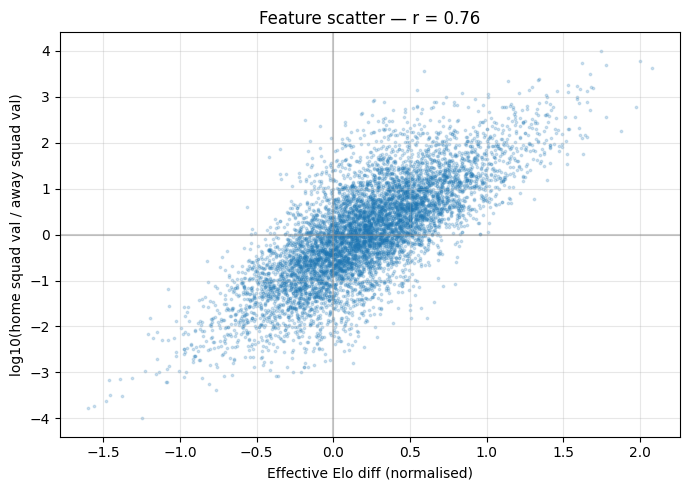

In [5]:
corr = valid[['elo_diff_norm', 'log_value_diff']].corr().iloc[0, 1]
print(f'Correlation between Elo diff and log value diff: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['elo_diff_norm'], valid['log_value_diff'], s=3, alpha=0.2)
ax.axhline(0, color='gray', alpha=0.4)
ax.axvline(0, color='gray', alpha=0.4)
ax.set_xlabel('Effective Elo diff (normalised)')
ax.set_ylabel('log10(home squad val / away squad val)')
ax.set_title(f'Feature scatter — r = {corr:.2f}')
ax.grid(alpha=0.3)
plt.tight_layout()

## Walk-forward backtest: WC 2010–2022

For each WC year, train both models on all prior eligible matches and evaluate on the WC matches that year.

In [6]:
def fit_logit(X, y):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X, y)
    return clf

def predict_3way(clf, X):
    proba = clf.predict_proba(X)
    classes = list(clf.classes_)
    order = [classes.index(c) for c in (0, 1, 2)]
    return proba[:, order]

def score(y_true, proba):
    p = np.clip(proba, 1e-6, 1 - 1e-6)
    return {
        'log_loss': log_loss(y_true, p, labels=[0, 1, 2]),
        'accuracy': float((p.argmax(axis=1) == y_true).mean()),
        'home_acc': float(((p[:, 2] > 0.5).astype(int) == (y_true == 2).astype(int)).mean()),
        'home_ll':  float(log_loss((y_true == 2).astype(int), p[:, 2])),
    }

rows = []
test_preds = {}
for year in [2010, 2014, 2018, 2022]:
    train = valid[valid['date'].dt.year < year]
    test = valid[(valid['date'].dt.year == year) & (valid['tournament'] == 'FIFA World Cup')]
    if test.empty:
        continue

    y_train = train['outcome'].to_numpy()
    y_test = test['outcome'].to_numpy()

    X1_train = train[['elo_diff_norm']].to_numpy()
    X1_test  = test[['elo_diff_norm']].to_numpy()
    X2_train = train[['elo_diff_norm', 'log_value_diff']].to_numpy()
    X2_test  = test[['elo_diff_norm', 'log_value_diff']].to_numpy()

    clf1 = fit_logit(X1_train, y_train)
    clf2 = fit_logit(X2_train, y_train)
    p1 = predict_3way(clf1, X1_test)
    p2 = predict_3way(clf2, X2_test)

    s1 = score(y_test, p1)
    s2 = score(y_test, p2)
    rows.append({
        'year': year, 'n_train': len(train), 'n_test': len(test),
        'logit1_ll': s1['log_loss'], 'logit2_ll': s2['log_loss'],
        'logit1_acc': s1['accuracy'], 'logit2_acc': s2['accuracy'],
        'logit1_home_ll': s1['home_ll'], 'logit2_home_ll': s2['home_ll'],
        'value_coef': float(clf2.coef_.mean(axis=0)[1]),
    })
    test_preds[year] = (test.assign(p_away_1=p1[:,0], p_draw_1=p1[:,1], p_home_1=p1[:,2],
                                    p_away_2=p2[:,0], p_draw_2=p2[:,1], p_home_2=p2[:,2]))

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))
print()
print('Averages:')
print(f"  Elo-only          log_loss: {results['logit1_ll'].mean():.4f}   accuracy: {results['logit1_acc'].mean():.4f}")
print(f"  Elo + squad value log_loss: {results['logit2_ll'].mean():.4f}   accuracy: {results['logit2_acc'].mean():.4f}")
print(f"  Delta log_loss: {results['logit2_ll'].mean() - results['logit1_ll'].mean():+.4f} (negative = improvement)")
print(f"  Delta accuracy: {results['logit2_acc'].mean() - results['logit1_acc'].mean():+.4f}")

 year  n_train  n_test  logit1_ll  logit2_ll  logit1_acc  logit2_acc  logit1_home_ll  logit2_home_ll  value_coef
 2010     1442      61     1.0626     1.0390      0.4918      0.5246          0.6391          0.6283         0.0
 2014     2782      58     0.9969     0.9630      0.5690      0.5690          0.6392          0.5953         0.0
 2018     4147      64     1.0560     1.0005      0.5000      0.4844          0.6537          0.6014         0.0
 2022     5751      64     1.1237     1.0620      0.4531      0.5312          0.7458          0.6874         0.0

Averages:
  Elo-only          log_loss: 1.0598   accuracy: 0.5035
  Elo + squad value log_loss: 1.0161   accuracy: 0.5273
  Delta log_loss: -0.0437 (negative = improvement)
  Delta accuracy: +0.0238


## Where do the two models disagree?

Find WC matches where adding squad value changed the picked outcome (argmax flipped).

In [7]:
diffs = []
for year, preds in test_preds.items():
    p1 = preds[['p_away_1', 'p_draw_1', 'p_home_1']].to_numpy()
    p2 = preds[['p_away_2', 'p_draw_2', 'p_home_2']].to_numpy()
    flipped = p1.argmax(axis=1) != p2.argmax(axis=1)
    sub = preds[flipped][['date', 'home_team', 'away_team', 'home_score', 'away_score']].copy()
    sub['logit1_pick'] = pd.Series(p1.argmax(axis=1)[flipped]).map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['logit2_pick'] = pd.Series(p2.argmax(axis=1)[flipped]).map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['actual'] = preds[flipped]['outcome'].map({0: 'away', 1: 'draw', 2: 'home'}).values
    sub['p_home_1'] = p1[flipped, 2].round(2)
    sub['p_home_2'] = p2[flipped, 2].round(2)
    diffs.append(sub)

if diffs:
    flip = pd.concat(diffs, ignore_index=True)
    print(f'{len(flip)} WC matches where the pick flipped:')
    print(flip.to_string(index=False))
else:
    print('No argmax flips — features mostly agree.')

36 WC matches where the pick flipped:


      date    home_team     away_team  home_score  away_score logit1_pick logit2_pick actual  p_home_1  p_home_2
2010-06-12    Argentina       Nigeria         1.0         0.0        away        home   home      0.25      0.41
2010-06-13       Serbia         Ghana         0.0         1.0        away        home   away      0.31      0.41
2010-06-15  New Zealand      Slovakia         1.0         1.0        home        away   draw      0.39      0.33
2010-06-17    Argentina   South Korea         4.0         1.0        away        home   home      0.24      0.44
2010-06-17       France        Mexico         0.0         2.0        away        home   away      0.22      0.38
2010-06-19        Ghana     Australia         1.0         1.0        away        home   draw      0.36      0.43
2010-06-21        Chile   Switzerland         1.0         0.0        away        home   home      0.32      0.38
2010-06-26      Uruguay   South Korea         2.0         1.0        away        home   home   

## Squad-value coefficient over time

If the coefficient is consistently positive and stable, the feature is contributing real signal.

In [8]:
print(results[['year', 'value_coef']].to_string(index=False))
print()
print('Reminder: `value_coef` is the average per-class coefficient on log_value_diff.')
print('In multinomial logit with 3 classes, individual class coefs sum to ~0;')
print('the home-win class typically gets the positive weight when home has more squad value.')

 year   value_coef
 2010 5.181041e-16
 2014 3.700743e-17
 2018 1.036208e-15
 2022 6.661338e-16

Reminder: `value_coef` is the average per-class coefficient on log_value_diff.
In multinomial logit with 3 classes, individual class coefs sum to ~0;
the home-win class typically gets the positive weight when home has more squad value.
